# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
import pandas as pd


In [2]:
postings = pd.read_csv("../data/postings.csv")

In [3]:
# Reading CSV files from /mappings/
industries = pd.read_csv("../data/mappings/industries.csv")
skills = pd.read_csv("../data/mappings/skills.csv")

In [4]:
# Reading CSV files from /jobs/
benefits = pd.read_csv("../data/jobs/benefits.csv")
job_industries = pd.read_csv("../data/jobs/job_industries.csv")
job_skills = pd.read_csv("../data/jobs/job_skills.csv")
salaries = pd.read_csv("../data/jobs/salaries.csv")

In [5]:
# Reading CSV files from /companies/
companies = pd.read_csv("../data/companies/companies.csv")
company_industries = pd.read_csv("../data/companies/company_industries.csv")
company_specialities = pd.read_csv("../data/companies/company_specialities.csv")
employee_counts = pd.read_csv("../data/companies/employee_counts.csv")

Number of records in each table:
postings: 123849
industries: 422
skills: 35
benefits: 67943
job_industries: 164808
job_skills: 213768
salaries: 40785
companies: 24473
company_industries: 24375
company_specialities: 169387
employee_counts: 35787

Total number of records: 865632


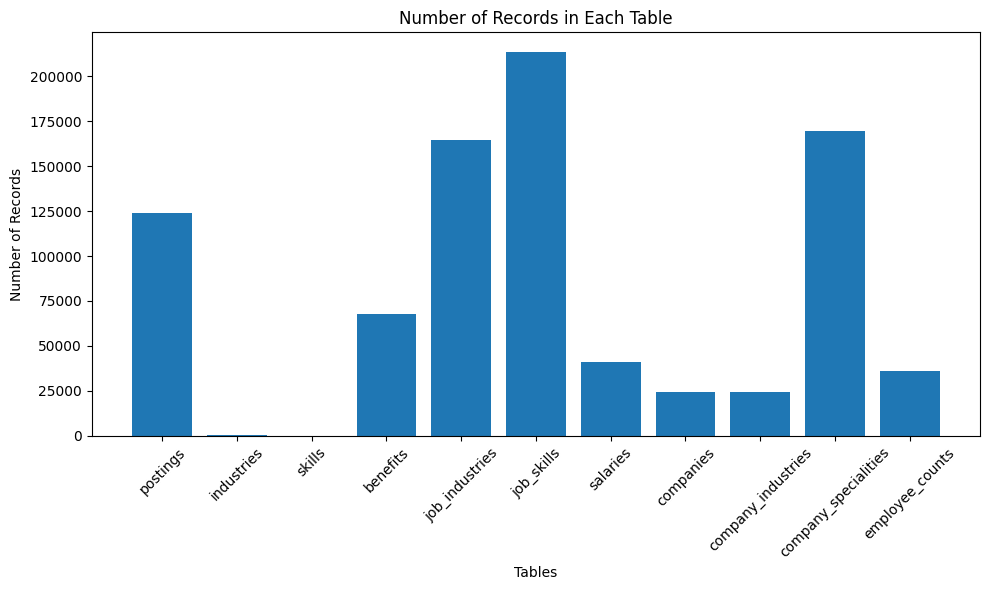

In [6]:
import matplotlib.pyplot as plt

dataframes = {
    "postings": postings,
    "industries": industries,
    "skills": skills,
    "benefits": benefits,
    "job_industries": job_industries,
    "job_skills": job_skills,
    "salaries": salaries,
    "companies": companies,
    "company_industries": company_industries,
    "company_specialities": company_specialities,
    "employee_counts": employee_counts
}

# Calculating the number of records in each DataFrame
record_counts = {name: len(df) for name, df in dataframes.items()}

# Calculating the total number of records
total_records = sum(record_counts.values())
# Printing the number of records in each DataFrame and the total number of records
print("Number of records in each table:")
for name, count in record_counts.items():
    print(f"{name}: {count}")
print(f"\nTotal number of records: {total_records}")

# Plotting the number of records in each DataFrame
plt.figure(figsize=(10, 6))
plt.bar(record_counts.keys(), record_counts.values())
plt.xlabel('Tables')
plt.ylabel('Number of Records')
plt.title('Number of Records in Each Table')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
from faker import Faker
import random
from datetime import datetime, timedelta

fake = Faker()

# Load existing data
postings = pd.read_csv("../data/postings.csv")
industries = pd.read_csv("../data/mappings/industries.csv")
skills = pd.read_csv("../data/mappings/skills.csv")
benefits = pd.read_csv("../data/jobs/benefits.csv")
job_industries = pd.read_csv("../data/jobs/job_industries.csv")
job_skills = pd.read_csv("../data/jobs/job_skills.csv")
salaries = pd.read_csv("../data/jobs/salaries.csv")
companies = pd.read_csv("../data/companies/companies.csv")
company_industries = pd.read_csv("../data/companies/company_industries.csv")
company_specialities = pd.read_csv("../data/companies/company_specialities.csv")
employee_counts = pd.read_csv("../data/companies/employee_counts.csv")

# Calculate the current number of records
total_records = len(postings) + len(industries) + len(skills) + len(benefits) + len(job_industries) + \
                len(job_skills) + len(salaries) + len(companies) + len(company_industries) + \
                len(company_specialities) + len(employee_counts)

# Calculate the number of additional records needed
target_records = 1700000
additional_records = target_records - total_records

# Determine how many additional records to generate for each table
additional_postings = int(additional_records * 0.25)
additional_companies = int(additional_records * 0.05)
additional_job_skills = int(additional_records * 0.2)
additional_job_industries = int(additional_records * 0.15)
additional_benefits = int(additional_records * 0.1)
additional_salaries = int(additional_records * 0.05)
additional_company_industries = int(additional_records * 0.05)
additional_company_specialities = int(additional_records * 0.05)
additional_employee_counts = int(additional_records * 0.05)
additional_industries = int(additional_records * 0.025)
additional_skills = int(additional_records * 0.025)

# Generate additional companies
new_companies = []
max_company_id = companies["company_id"].max()
for i in range(additional_companies):
    new_companies.append({
        "company_id": max_company_id + i + 1,
        "name": fake.company(),
        "description": fake.text(),
        "company_size": fake.random_element(elements=("Small", "Medium", "Large", "Enterprise")),
        "state": fake.state_abbr(),
        "country": fake.country(),
        "city": fake.city(),
        "zip_code": fake.zipcode(),
        "address": fake.street_address(),
        "url": fake.url()
    })

df_new_companies = pd.DataFrame(new_companies)

# Generate additional postings
new_postings = []
max_job_id = postings["job_id"].max()
all_company_ids = list(companies["company_id"]) + [comp["company_id"] for comp in new_companies]

for i in range(additional_postings):
    new_postings.append({
        "job_id": max_job_id + i + 1,
        "company_id": random.choice(all_company_ids),
        "company_name": fake.company(),
        "title": fake.job(),
        "description": fake.text(),
        "max_salary": random.uniform(50000, 200000),
        "pay_period": fake.random_element(elements=("Yearly", "Monthly", "Weekly", "Hourly")),
        "location": fake.city(),
        "views": random.randint(0, 10000),
        "med_salary": random.uniform(50000, 200000),
        "min_salary": random.uniform(50000, 200000),
        "formatted_work_type": fake.random_element(elements=("Full-time", "Part-time", "Contract")),
        "applies": random.randint(0, 1000),
        "original_listed_time": fake.date_time_this_decade(),
        "remote_allowed": random.randint(0, 1),
        "job_posting_url": fake.url(),
        "application_url": fake.url(),
        "application_type": fake.random_element(elements=("Direct", "Third-party")),
        "expiry": fake.date_time_this_decade(),
        "closed_time": fake.date_time_this_decade(),
        "formatted_experience_level": fake.random_element(elements=("Entry", "Mid", "Senior")),
        "skills_desc": fake.text(),
        "listed_time": fake.date_time_this_decade(),
        "posting_domain": fake.domain_name(),
        "sponsored": random.randint(0, 1),
        "work_type": fake.random_element(elements=("On-site", "Remote", "Hybrid")),
        "currency": fake.currency_code(),
        "compensation_type": fake.random_element(elements=("Base", "Bonus", "Commission")),
        "normalized_salary": random.uniform(50000, 200000),
        "zip_code": fake.zipcode(),
        "fips": fake.zipcode()
    })

df_new_postings = pd.DataFrame(new_postings)

# Generate additional industries
new_industries = []
max_industry_id = industries["industry_id"].max()
for i in range(additional_industries):
    new_industries.append({
        "industry_id": max_industry_id + i + 1,
        "industry_name": fake.job()
    })

df_new_industries = pd.DataFrame(new_industries)

# Generate additional skills
new_skills = []
existing_skill_abr = set(skills["skill_abr"])
for _ in range(additional_skills):
    skill_abr = fake.lexify(text="????").upper()
    # Ensure uniqueness
    while skill_abr in existing_skill_abr:
        skill_abr = fake.lexify(text="????").upper()
    existing_skill_abr.add(skill_abr)
    new_skills.append({
        "skill_abr": skill_abr,
        "skill_name": fake.job()
    })

df_new_skills = pd.DataFrame(new_skills)

# Generate additional job_skills
new_job_skills = []
all_job_ids = list(postings["job_id"]) + [job["job_id"] for job in new_postings]
all_skill_abrs = list(skills["skill_abr"]) + [skill["skill_abr"] for skill in new_skills]

for _ in range(additional_job_skills):
    job_id = random.choice(all_job_ids)
    skill_abr = random.choice(all_skill_abrs)
    new_job_skills.append({
        "job_id": job_id,
        "skill_abr": skill_abr
    })

df_new_job_skills = pd.DataFrame(new_job_skills)
df_new_job_skills = df_new_job_skills.drop_duplicates(subset=["job_id", "skill_abr"])

# Generate additional job_industries
new_job_industries = []
all_industry_ids = list(industries["industry_id"]) + [ind["industry_id"] for ind in new_industries]

for _ in range(additional_job_industries):
    job_id = random.choice(all_job_ids)
    industry_id = random.choice(all_industry_ids)
    new_job_industries.append({
        "job_id": job_id,
        "industry_id": industry_id
    })

df_new_job_industries = pd.DataFrame(new_job_industries)
df_new_job_industries = df_new_job_industries.drop_duplicates(subset=["job_id", "industry_id"])

# Generate additional benefits
new_benefits = []
benefit_types = ["Health Insurance", "Dental Insurance", "Vision Insurance", "401K", "PTO",
                "Flexible Schedule", "Remote Work", "Gym Membership", "Stock Options",
                "Company Car", "Professional Development"]

for _ in range(additional_benefits):
    job_id = random.choice(all_job_ids)
    benefit_type = random.choice(benefit_types)
    new_benefits.append({
        "job_id": job_id,
        "inferred": random.randint(0, 1),
        "type": benefit_type
    })

df_new_benefits = pd.DataFrame(new_benefits)
df_new_benefits = df_new_benefits.drop_duplicates(subset=["job_id", "type"])

# Generate additional salaries
new_salaries = []
max_salary_id = salaries["salary_id"].max() if not salaries.empty else 0

for i in range(additional_salaries):
    job_id = random.choice(all_job_ids)
    min_val = random.uniform(30000, 100000)
    med_val = min_val + random.uniform(5000, 30000)
    max_val = med_val + random.uniform(5000, 50000)
    new_salaries.append({
        "salary_id": max_salary_id + i + 1,
        "job_id": job_id,
        "max_salary": max_val,
        "med_salary": med_val,
        "min_salary": min_val,
        "pay_period": fake.random_element(elements=("Yearly", "Monthly", "Weekly", "Hourly")),
        "currency": fake.currency_code(),
        "compensation_type": fake.random_element(elements=("Base", "Bonus", "Commission"))
    })

df_new_salaries = pd.DataFrame(new_salaries)

# Generate additional company_industries
new_company_industries = []

for _ in range(additional_company_industries):
    company_id = random.choice(all_company_ids)
    industry = fake.job()
    new_company_industries.append({
        "company_id": company_id,
        "industry": industry
    })

df_new_company_industries = pd.DataFrame(new_company_industries)
df_new_company_industries = df_new_company_industries.drop_duplicates(subset=["company_id", "industry"])

# Generate additional company_specialities
new_company_specialities = []
specialities = ["AI", "Machine Learning", "Web Development", "Mobile Apps", "Cloud Computing",
                "DevOps", "Big Data", "IoT", "Blockchain", "Cybersecurity", "E-commerce"]

for _ in range(additional_company_specialities):
    company_id = random.choice(all_company_ids)
    speciality = random.choice(specialities)
    new_company_specialities.append({
        "company_id": company_id,
        "speciality": speciality
    })

df_new_company_specialities = pd.DataFrame(new_company_specialities)
df_new_company_specialities = df_new_company_specialities.drop_duplicates(subset=["company_id", "speciality"])

# Generate additional employee_counts
new_employee_counts = []
now = datetime.now()

for _ in range(additional_employee_counts):
    company_id = random.choice(all_company_ids)
    time_recorded = now - timedelta(days=random.randint(0, 365))
    new_employee_counts.append({
        "company_id": company_id,
        "employee_count": random.randint(10, 10000),
        "follower_count": random.randint(0, 50000),
        "time_recorded": time_recorded
    })

df_new_employee_counts = pd.DataFrame(new_employee_counts)
df_new_employee_counts = df_new_employee_counts.drop_duplicates(subset=["company_id", "time_recorded"])

# Append new records to existing DataFrames using pd.concat
postings = pd.concat([postings, df_new_postings], ignore_index=True)
industries = pd.concat([industries, df_new_industries], ignore_index=True)
skills = pd.concat([skills, df_new_skills], ignore_index=True)
benefits = pd.concat([benefits, df_new_benefits], ignore_index=True)
job_industries = pd.concat([job_industries, df_new_job_industries], ignore_index=True)
job_skills = pd.concat([job_skills, df_new_job_skills], ignore_index=True)
salaries = pd.concat([salaries, df_new_salaries], ignore_index=True)
companies = pd.concat([companies, df_new_companies], ignore_index=True)
company_industries = pd.concat([company_industries, df_new_company_industries], ignore_index=True)
company_specialities = pd.concat([company_specialities, df_new_company_specialities], ignore_index=True)
employee_counts = pd.concat([employee_counts, df_new_employee_counts], ignore_index=True)

# Save updated DataFrames back to CSV files
postings.to_csv("./data/postings.csv", index=False)
industries.to_csv("./data/mappings/industries.csv", index=False)
skills.to_csv("./data/mappings/skills.csv", index=False)
benefits.to_csv("./data/jobs/benefits.csv", index=False)
job_industries.to_csv("./data/jobs/job_industries.csv", index=False)
job_skills.to_csv("./data/jobs/job_skills.csv", index=False)
salaries.to_csv("./data/jobs/salaries.csv", index=False)
companies.to_csv("./data/companies/companies.csv", index=False)
company_industries.to_csv("./data/companies/company_industries.csv", index=False)
company_specialities.to_csv("./data/companies/company_specialities.csv", index=False)
employee_counts.to_csv("./data/companies/employee_counts.csv", index=False)

# Print summary of added records
print(f"Added {len(df_new_postings)} new postings")
print(f"Added {len(df_new_companies)} new companies")
print(f"Added {len(df_new_industries)} new industries")
print(f"Added {len(df_new_skills)} new skills")
print(f"Added {len(df_new_job_skills)} new job skills")
print(f"Added {len(df_new_job_industries)} new job industries")
print(f"Added {len(df_new_benefits)} new benefits")
print(f"Added {len(df_new_salaries)} new salaries")
print(f"Added {len(df_new_company_industries)} new company industries")
print(f"Added {len(df_new_company_specialities)} new company specialities")
print(f"Added {len(df_new_employee_counts)} new employee counts")

# Calculate updated total records
updated_total = len(postings) + len(industries) + len(skills) + len(benefits) + len(job_industries) + \
                len(job_skills) + len(salaries) + len(companies) + len(company_industries) + \
                len(company_specialities) + len(employee_counts)
print(f"Total records: {updated_total}")

Added 208592 new postings
Added 41718 new companies
Added 20859 new industries
Added 20859 new skills
Added 166872 new job skills
Added 125155 new job industries
Added 82466 new benefits
Added 41718 new salaries
Added 41696 new company industries
Added 40442 new company specialities
Added 41682 new employee counts
Total records: 1697691


Number of records in each table:
postings: 332,441
industries: 21,281
skills: 20,894
benefits: 150,409
job_industries: 289,963
job_skills: 380,640
salaries: 82,503
companies: 66,191
company_industries: 66,071
company_specialities: 209,829
employee_counts: 77,469

Total number of records: 1,697,691


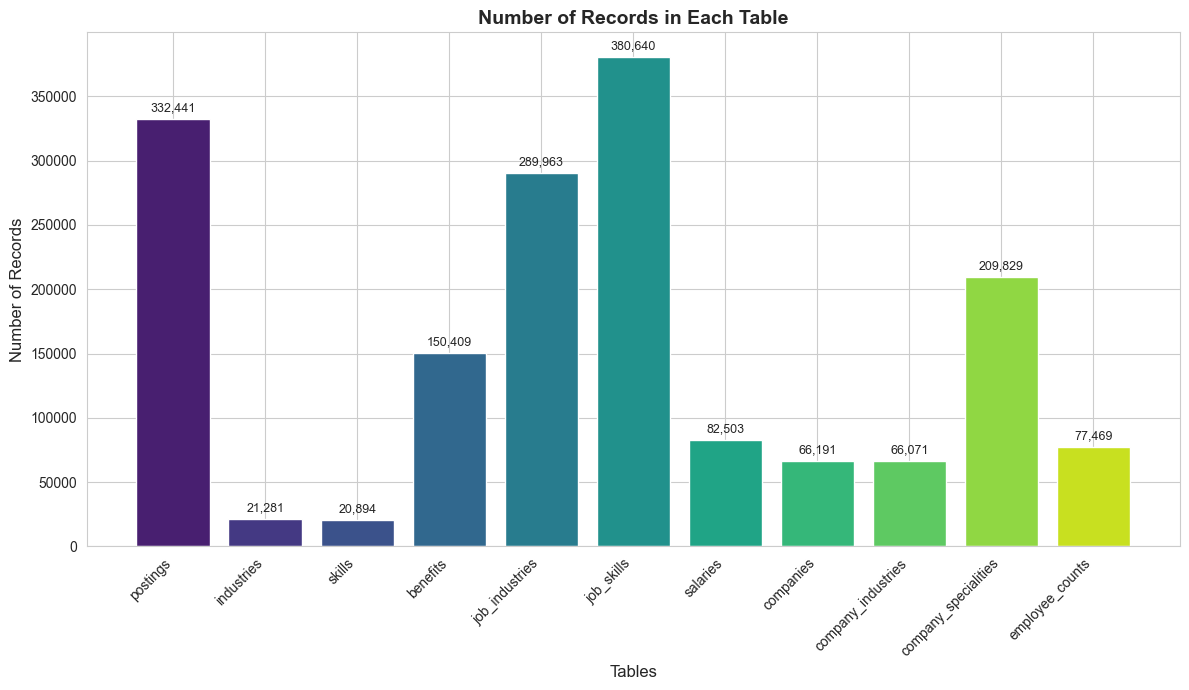

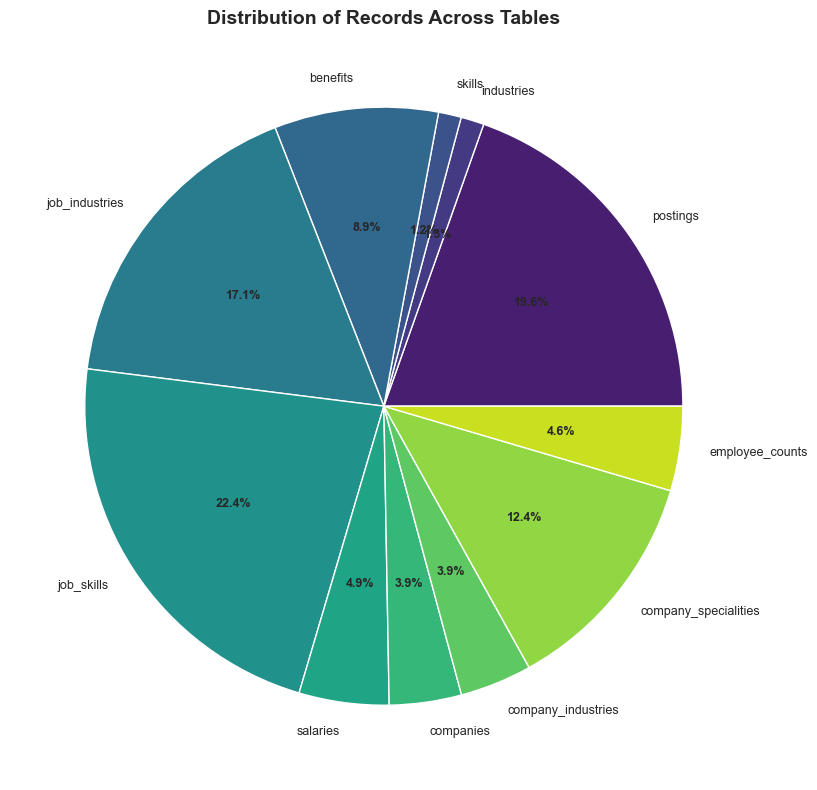

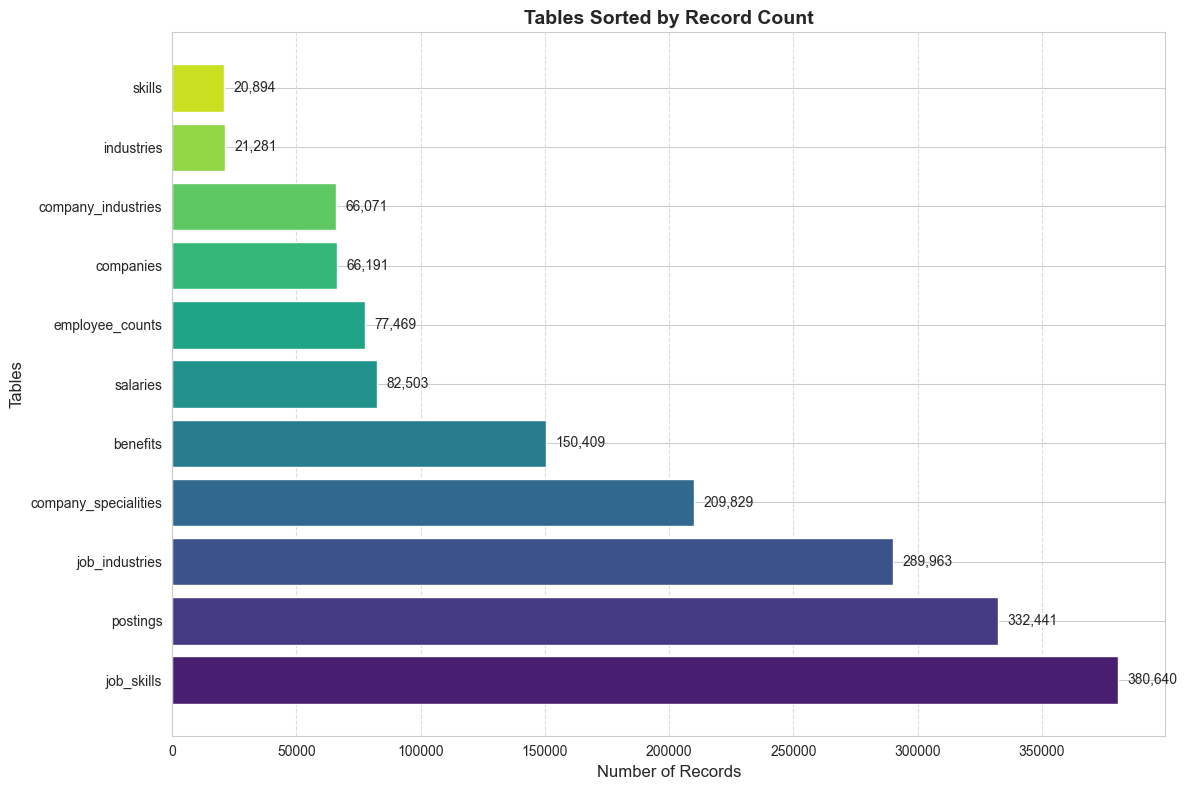

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a dictionary of dataframes
dataframes = {
    "postings": postings,
    "industries": industries,
    "skills": skills,
    "benefits": benefits,
    "job_industries": job_industries,
    "job_skills": job_skills,
    "salaries": salaries,
    "companies": companies,
    "company_industries": company_industries,
    "company_specialities": company_specialities,
    "employee_counts": employee_counts
}

# Calculate the number of records in each DataFrame
record_counts = {name: len(df) for name, df in dataframes.items()}

# Calculate the total number of records
total_records = sum(record_counts.values())

# Print the number of records in each DataFrame and the total
print("Number of records in each table:")
for name, count in record_counts.items():
    print(f"{name}: {count:,}")
print(f"\nTotal number of records: {total_records:,}")

# Create a more visually appealing bar plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
bars = plt.bar(
    record_counts.keys(),
    record_counts.values(),
    color=sns.color_palette("viridis", len(record_counts))
)

# Add data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.01 * max(record_counts.values()),
        f'{int(height):,}',
        ha='center',
        va='bottom',
        rotation=0,
        fontsize=9
    )

plt.xlabel('Tables', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.title('Number of Records in Each Table', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Create a pie chart showing the distribution of records
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    record_counts.values(),
    labels=record_counts.keys(),
    autopct='%1.1f%%',
    textprops={'fontsize': 9},
    colors=sns.color_palette("viridis", len(record_counts))
)
plt.setp(autotexts, size=9, weight="bold")
plt.title('Distribution of Records Across Tables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Create a horizontal bar chart sorted by count
plt.figure(figsize=(12, 8))
sorted_counts = {k: v for k, v in sorted(record_counts.items(), key=lambda item: item[1], reverse=True)}
bars = plt.barh(
    list(sorted_counts.keys()),
    list(sorted_counts.values()),
    color=sns.color_palette("viridis", len(sorted_counts))
)

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01 * max(sorted_counts.values()),
        bar.get_y() + bar.get_height()/2.,
        f'{int(width):,}',
        ha='left',
        va='center',
        fontsize=10
    )

plt.xlabel('Number of Records', fontsize=12)
plt.ylabel('Tables', fontsize=12)
plt.title('Tables Sorted by Record Count', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import numpy as np

# Check for primary key uniqueness
def check_primary_keys():
    print("Checking primary key uniqueness...")

    # Check postings table
    duplicates = postings['job_id'].duplicated().sum()
    print(f"Duplicate job_ids in postings: {duplicates}")

    # Check companies table
    duplicates = companies['company_id'].duplicated().sum()
    print(f"Duplicate company_ids in companies: {duplicates}")

    # Check industries table
    duplicates = industries['industry_id'].duplicated().sum()
    print(f"Duplicate industry_ids in industries: {duplicates}")

    # Check skills table
    duplicates = skills['skill_abr'].duplicated().sum()
    print(f"Duplicate skill_abrs in skills: {duplicates}")

    # Check salaries table
    duplicates = salaries['salary_id'].duplicated().sum()
    print(f"Duplicate salary_ids in salaries: {duplicates}")

    # Check composite primary keys
    duplicates = job_industries.duplicated(subset=['job_id', 'industry_id']).sum()
    print(f"Duplicate job_id-industry_id pairs in job_industries: {duplicates}")

    duplicates = job_skills.duplicated(subset=['job_id', 'skill_abr']).sum()
    print(f"Duplicate job_id-skill_abr pairs in job_skills: {duplicates}")

    duplicates = benefits.duplicated(subset=['job_id', 'type']).sum()
    print(f"Duplicate job_id-type pairs in benefits: {duplicates}")

    duplicates = company_industries.duplicated(subset=['company_id', 'industry']).sum()
    print(f"Duplicate company_id-industry pairs in company_industries: {duplicates}")

    duplicates = company_specialities.duplicated(subset=['company_id', 'speciality']).sum()
    print(f"Duplicate company_id-speciality pairs in company_specialities: {duplicates}")

    duplicates = employee_counts.duplicated(subset=['company_id', 'time_recorded']).sum()
    print(f"Duplicate company_id-time_recorded pairs in employee_counts: {duplicates}")

# Check foreign key integrity
def check_foreign_keys():
    print("\nChecking foreign key integrity...")

    # Check job_id references in various tables
    valid_job_ids = set(postings['job_id'])

    invalid_job_ids = job_industries[~job_industries['job_id'].isin(valid_job_ids)].shape[0]
    print(f"Invalid job_ids in job_industries: {invalid_job_ids}")

    invalid_job_ids = job_skills[~job_skills['job_id'].isin(valid_job_ids)].shape[0]
    print(f"Invalid job_ids in job_skills: {invalid_job_ids}")

    invalid_job_ids = benefits[~benefits['job_id'].isin(valid_job_ids)].shape[0]
    print(f"Invalid job_ids in benefits: {invalid_job_ids}")

    invalid_job_ids = salaries[~salaries['job_id'].isin(valid_job_ids)].shape[0]
    print(f"Invalid job_ids in salaries: {invalid_job_ids}")

    # Check company_id references
    valid_company_ids = set(companies['company_id'])

    invalid_company_ids = postings[~postings['company_id'].isin(valid_company_ids)].shape[0]
    print(f"Invalid company_ids in postings: {invalid_company_ids}")

    invalid_company_ids = company_industries[~company_industries['company_id'].isin(valid_company_ids)].shape[0]
    print(f"Invalid company_ids in company_industries: {invalid_company_ids}")

    invalid_company_ids = company_specialities[~company_specialities['company_id'].isin(valid_company_ids)].shape[0]
    print(f"Invalid company_ids in company_specialities: {invalid_company_ids}")

    invalid_company_ids = employee_counts[~employee_counts['company_id'].isin(valid_company_ids)].shape[0]
    print(f"Invalid company_ids in employee_counts: {invalid_company_ids}")

    # Check other references
    valid_industry_ids = set(industries['industry_id'])
    invalid_industry_ids = job_industries[~job_industries['industry_id'].isin(valid_industry_ids)].shape[0]
    print(f"Invalid industry_ids in job_industries: {invalid_industry_ids}")

    valid_skill_abrs = set(skills['skill_abr'])
    invalid_skill_abrs = job_skills[~job_skills['skill_abr'].isin(valid_skill_abrs)].shape[0]
    print(f"Invalid skill_abrs in job_skills: {invalid_skill_abrs}")

# Check data types and constraints
def check_data_types():
    print("\nChecking data types and constraints...")

    # Check for NULL values in primary keys
    print(f"NULL job_ids in postings: {postings['job_id'].isnull().sum()}")
    print(f"NULL company_ids in companies: {companies['company_id'].isnull().sum()}")
    print(f"NULL industry_ids in industries: {industries['industry_id'].isnull().sum()}")
    print(f"NULL skill_abrs in skills: {skills['skill_abr'].isnull().sum()}")
    print(f"NULL salary_ids in salaries: {salaries['salary_id'].isnull().sum()}")

    # Check datetime formats
    date_columns = [
        (postings, 'original_listed_time'),
        (postings, 'expiry'),
        (postings, 'closed_time'),
        (postings, 'listed_time'),
        (employee_counts, 'time_recorded')
    ]

    for df, col in date_columns:
        try:
            pd.to_datetime(df[col], errors='raise')
            print(f"Valid datetime format in {col}")
        except:
            print(f"Invalid datetime format in {col}")

In [10]:
check_primary_keys()
check_foreign_keys()
check_data_types()


Checking primary key uniqueness...
Duplicate job_ids in postings: 0
Duplicate company_ids in companies: 0
Duplicate industry_ids in industries: 0
Duplicate skill_abrs in skills: 0
Duplicate salary_ids in salaries: 0
Duplicate job_id-industry_id pairs in job_industries: 3
Duplicate job_id-skill_abr pairs in job_skills: 4
Duplicate job_id-type pairs in benefits: 0
Duplicate company_id-industry pairs in company_industries: 0
Duplicate company_id-speciality pairs in company_specialities: 91
Duplicate company_id-time_recorded pairs in employee_counts: 122

Checking foreign key integrity...
Invalid job_ids in job_industries: 5845
Invalid job_ids in job_skills: 7990
Invalid job_ids in benefits: 2550
Invalid job_ids in salaries: 4712
Invalid company_ids in postings: 1718
Invalid company_ids in company_industries: 0
Invalid company_ids in company_specialities: 0
Invalid company_ids in employee_counts: 0
Invalid industry_ids in job_industries: 0
Invalid skill_abrs in job_skills: 0

Checking data

In [11]:
job_industries = job_industries.drop_duplicates(subset=['job_id', 'industry_id'])
job_skills = job_skills.drop_duplicates(subset=['job_id', 'skill_abr'])
company_specialities = company_specialities.drop_duplicates(subset=['company_id', 'speciality'])
employee_counts = employee_counts.drop_duplicates(subset=['company_id', 'time_recorded'])

In [12]:
valid_job_ids = set(postings['job_id'])
valid_company_ids = set(companies['company_id'])

# Filter out invalid foreign key references
job_industries = job_industries[job_industries['job_id'].isin(valid_job_ids)]
job_skills = job_skills[job_skills['job_id'].isin(valid_job_ids)]
benefits = benefits[benefits['job_id'].isin(valid_job_ids)]
salaries = salaries[salaries['job_id'].isin(valid_job_ids)]
postings = postings[postings['company_id'].isin(valid_company_ids)]

In [13]:
check_primary_keys()
check_foreign_keys()
check_data_types()

Checking primary key uniqueness...
Duplicate job_ids in postings: 0
Duplicate company_ids in companies: 0
Duplicate industry_ids in industries: 0
Duplicate skill_abrs in skills: 0
Duplicate salary_ids in salaries: 0
Duplicate job_id-industry_id pairs in job_industries: 0
Duplicate job_id-skill_abr pairs in job_skills: 0
Duplicate job_id-type pairs in benefits: 0
Duplicate company_id-industry pairs in company_industries: 0
Duplicate company_id-speciality pairs in company_specialities: 0
Duplicate company_id-time_recorded pairs in employee_counts: 0

Checking foreign key integrity...
Invalid job_ids in job_industries: 1236
Invalid job_ids in job_skills: 3411
Invalid job_ids in benefits: 1005
Invalid job_ids in salaries: 720
Invalid company_ids in postings: 0
Invalid company_ids in company_industries: 0
Invalid company_ids in company_specialities: 0
Invalid company_ids in employee_counts: 0
Invalid industry_ids in job_industries: 0
Invalid skill_abrs in job_skills: 0

Checking data types 

In [14]:
print("Number of records in each table:")
for name, count in record_counts.items():
    print(f"{name}: {count:,}")
print(f"\nTotal number of records: {total_records:,}")

Number of records in each table:
postings: 332,441
industries: 21,281
skills: 20,894
benefits: 150,409
job_industries: 289,963
job_skills: 380,640
salaries: 82,503
companies: 66,191
company_industries: 66,071
company_specialities: 209,829
employee_counts: 77,469

Total number of records: 1,697,691
